Install & Import Libraries

In [ ]:
!pip install tensorflow opencv-python pillow



import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models




Import Dataset

In [ ]:
from google.colab import files
upload = files.upload()


Saving doctor_handwriting_labels.csv to doctor_handwriting_labels.csv


Unzip Image Dataset (FIXED)

In [ ]:
!unzip img.zip -d /content/img

Archive:  img.zip
   creating: /content/img/img/
  inflating: /content/img/img/.trashed-1730798177-IMG_20241006_140831 - Copy (2).jpg  
  inflating: /content/img/img/.trashed-1730798177-IMG_20241006_140831 - Copy (3).jpg  
  inflating: /content/img/img/.trashed-1730802496-IMG_20241006_151957 - Copy (2).jpg  
  inflating: /content/img/img/img 10.jpg  
  inflating: /content/img/img/img 11.jpg  
  inflating: /content/img/img/img 12.jpg  
  inflating: /content/img/img/img 13.jpg  
  inflating: /content/img/img/img 14.jpg  
  inflating: /content/img/img/img 15.jpg  
  inflating: /content/img/img/img 16.jpg  
  inflating: /content/img/img/img 17.jpg  
  inflating: /content/img/img/img 18.jpg  
  inflating: /content/img/img/img 19.jpg  
  inflating: /content/img/img/img 20.jpg  
  inflating: /content/img/img/img 21.jpg  
  inflating: /content/img/img/img 22.jpg  
  inflating: /content/img/img/img 23.jpg  
  inflating: /content/img/img/img 24.jpg  
  inflating: /content/img/img/img 25.jpg  
  

Load Dataset

In [ ]:
df = pd.read_csv("/content/doctor_handwriting_labels.csv")

IMAGE_DIR = "/content/img/img"
IMG_WIDTH = 128
IMG_HEIGHT = 32

In [ ]:
df.head()


,filename,label
0,.trashed-1730802496-IMG_20241006_151957 - Copy...,cefiget 40mg
1,IMG_20241006_141949 - Copy.jpg,tab azimax
2,IMG_20241006_142328 - Copy.jpg,tab toniflex
3,IMG_20241006_142533 - Copy.jpg,nims
4,IMG_20241006_142757 - Copy.jpg,dicloran


Character Set & Encoding

In [ ]:
characters = sorted(list(set("".join(df['label']))))

char_to_num = layers.StringLookup(vocabulary=characters, mask_token=None)
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), invert=True
)

max_label_length = max(df['label'].str.len())

print("Characters:", characters)
print("Max label length:", max_label_length)


Characters: [' ', '-', '0', '1', '2', '4', '5', '6', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z']
Max label length: 17


Image Preprocessing Function

In [ ]:
def load_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img


Dataset Generator

In [ ]:
def _load_image_from_path(img_path_tensor):

    img_path = img_path_tensor.numpy().decode('utf-8')
    return load_image(img_path)

def encode_sample(row):
    filename_tensor = row['filename']
    label_tensor = row['label']


    full_img_path_tensor = tf.strings.join([tf.constant(IMAGE_DIR), filename_tensor], separator='/')


    image = tf.py_function(
        func=_load_image_from_path,
        inp=[full_img_path_tensor],
        Tout=tf.float32
    ) # Added the missing closing parenthesis here


    image.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])


    label = tf.strings.unicode_split(label_tensor, "UTF-8")
    label = char_to_num(label)


    padding = tf.zeros([max_label_length - tf.shape(label)[0]], dtype=tf.int64)
    padded_label = tf.concat([label, padding], axis=0)
    padded_label.set_shape([max_label_length])

    return {"image": image, "label": padded_label}

dataset = tf.data.Dataset.from_tensor_slices(dict(df))
dataset = dataset.map(encode_sample)

train_size = int(0.8 * len(df))
train_ds = dataset.take(train_size).batch(16)
val_ds = dataset.skip(train_size).batch(16)

CTC Loss Layer

In [ ]:
class CTCLayer(layers.Layer):
    def call(self, y_true, y_pred):
        batch = tf.shape(y_true)[0]
        input_len = tf.shape(y_pred)[1]
        label_len = tf.shape(y_true)[1]


        input_len = input_len * tf.ones((batch, 1), dtype="int32")
        label_len = label_len * tf.ones((batch, 1), dtype="int32")

        loss = tf.keras.backend.ctc_batch_cost(
            y_true, y_pred, input_len, label_len
        )
        self.add_loss(loss)
        return y_pred

Build CRNN Model

In [ ]:
image_input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="image")
label_input = layers.Input(name="label", shape=(None,), dtype="int32")

x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(image_input)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Reshape((IMG_WIDTH//4, (IMG_HEIGHT//4)*128))(x)

x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

x = layers.Dense(len(char_to_num.get_vocabulary()) + 1, activation="softmax")(x)

output = CTCLayer()(label_input, x)

model = models.Model([image_input, label_input], output)
model.compile(optimizer="adam")
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 128,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 128,   │        640 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 32,     │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 1024)  │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │  1,180,672 │ reshape[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32, 34)    │      4,386 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_layer           │ (None, 32, 34)    │          0 │ label[0][0],      │
│ (CTCLayer)          │                   │            │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,423,906 (5.43 MB)

 Trainable params: 1,423,906 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 860ms/step - loss: 1295.0210 - val_loss: 695.6924
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 861ms/step - loss: 806.8473 - val_loss: 653.2346
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 586ms/step - loss: 761.9086 - val_loss: 630.5881
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 590ms/step - loss: 730.6512 - val_loss: 597.5006
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 596ms/step - loss: 702.2557 - val_loss: 565.3440
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 868ms/step - loss: 683.3994 - val_loss: 543.0826
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 572ms/step - loss: 645.8685 - val_loss: 525.5404
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 574ms/step - loss: 637.5002 - val_loss: 515.0687
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 580ms/step - loss: 620.1044 - val_loss: 507.3278
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 853ms/step - loss: 610.8254 - val_loss: 498.9034
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 582ms/step - loss: 605.4977 - val_loss: 496.3874
Epoch 12/30
5/5 ━━━━━━━━━━━━

Prediction Model

In [ ]:
prediction_model = models.Model(
    image_input,
    model.layers[-2].output
)

def decode(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = tf.keras.backend.ctc_decode(pred, input_length=input_len)[0][0]
    texts = []
    for seq in decoded:
        text = "".join([num_to_char(c).numpy().decode() for c in seq if c != -1])
        texts.append(text)
    return texts

Test Prediction

In [ ]:
sample_img = load_image(os.path.join(IMAGE_DIR, df.iloc[0]['filename']))
sample_img = np.expand_dims(sample_img, axis=0)

prediction = prediction_model.predict(sample_img)
print("Predicted Text:", decode(prediction))
print("Actual Text:", df.iloc[0]['label'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Text: ['ta [UNK]']
Actual Text: cefiget 40mg


XAI Parts

In [ ]:
!pip install lime shap opencv-python


Accuracy Evaluation

In [ ]:
def evaluate_ocr(pred_model, dataset, df):
    correct_count = 0
    total_chars = 0
    correct_chars = 0

    for i, row in df.iterrows():
        img = load_image(os.path.join(IMAGE_DIR, row['filename']))
        img = np.expand_dims(img, axis=0)
        pred = pred_model.predict(img)
        pred_text = decode(pred)[0]

        true_text = row['label']

        # Exact match
        if pred_text == true_text:
            correct_count += 1

        # Character-level accuracy
        min_len = min(len(pred_text), len(true_text))
        for j in range(min_len):
            if pred_text[j] == true_text[j]:
                correct_chars += 1
        total_chars += len(true_text)

    exact_match_acc = correct_count / len(df)
    char_level_acc = correct_chars / total_chars

    return exact_match_acc, char_level_acc

exact_acc, char_acc = evaluate_ocr(prediction_model, val_ds, df)
print(f"Exact Match Accuracy: {exact_acc*100:.2f}%")
print(f"Character-level Accuracy: {char_acc*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


Explainable AI with LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

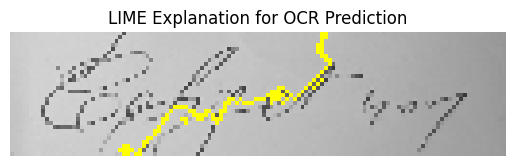

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import numpy as np


sample_img_rgb = gray2rgb(sample_img[:,:,0])

explainer = lime_image.LimeImageExplainer()

def ocr_predict(images_input_from_lime):
    processed_images = []
    for img in images_input_from_lime:
        # Convert RGB to grayscale (your model expects 1 channel)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (IMG_WIDTH, IMG_HEIGHT))
        img_4d = resized[:, :, np.newaxis].astype(np.float32)/255.0
        processed_images.append(img_4d)

    batch_images = np.array(processed_images, dtype=np.float32)
    tf_images = tf.convert_to_tensor(batch_images, dtype=tf.float32)

    preds = prediction_model.predict(tf_images, verbose=0)


    flattened = np.array([np.max(p, axis=-1) for p in preds])
    return flattened

# Explain the instance
explanation = explainer.explain_instance(
    sample_img_rgb,
    ocr_predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.title("LIME Explanation for OCR Prediction")
plt.show()


Explainable AI with SHAP

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image
Received: inputs=['Tensor(shape=(1, 32, 128, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image
Received: inputs=['Tensor(shape=(50, 32, 128, 1))']
  warnings.warn(msg)


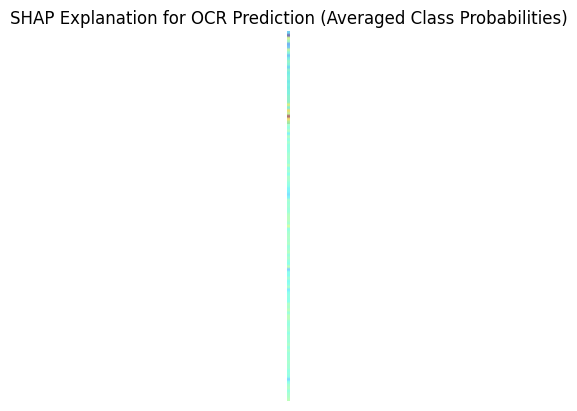

In [ ]:
import shap

# Create a SHAP-compatible model by taking the Global Average Pooling of the prediction_model's output
# The prediction_model's output has shape (None, IMG_WIDTH//4, num_classes)
# We want to reduce it to (None, num_classes) for SHAP GradientExplainer
shap_model_input = prediction_model.input
shap_model_output = layers.GlobalAveragePooling1D()(prediction_model.output)
shap_compatible_model = models.Model(inputs=shap_model_input, outputs=shap_model_output)


background = np.stack([load_image(os.path.join(IMAGE_DIR, f))[:,:,0] for f in df['filename'][:20]], axis=0)
background = np.expand_dims(background, -1)

# Use the newly created shap_compatible_model with GradientExplainer
e = shap.GradientExplainer(shap_compatible_model, background)

sample = np.expand_dims(sample_img, 0)
shap_values = e.shap_values(sample)

plt.imshow(sample_img[:,:,0], cmap='gray')
# shap_values[0] corresponds to the SHAP values for the first output class (first character in vocabulary)
# shap_values[0][0] corresponds to the first sample
plt.imshow(shap_values[0][0][:,:,0], cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("SHAP Explanation for OCR Prediction (Averaged Class Probabilities)")
plt.show()

Prediction + XAI

In [ ]:
sample_idx = 0
sample_img = load_image(os.path.join(IMAGE_DIR, df.iloc[sample_idx]['filename']))
sample_img_batch = np.expand_dims(sample_img, axis=0)

pred_text = decode(prediction_model.predict(sample_img_batch))[0]
true_text = df.iloc[sample_idx]['label']

print(f"Actual Text: {true_text}")
print(f"Predicted Text: {pred_text}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Actual Text: cefiget 40mg
Predicted Text: ta [UNK]
